In [1]:
import imageio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import RectangleSelector
import os
import numpy as np
import tifffile as tiff
import matplotlib

matplotlib.use('TkAgg')

In [70]:
#Load your TIFFs
LTP_pathA = r'\\Dulla_Synology\Interface Data\Rebecca\2024.08.06\08062024_Rebecca_GEVI\Slice1_CaMKII_ASAP3_1\outputs\rebecca_modified\Chan1_LTP_10794frames.tif'
LTP_pathN = r'\\Dulla_Synology\Interface Data\Rebecca\2024.08.06\08062024_Rebecca_GEVI\Slice1_CaMKII_ASAP3_1\outputs\rebecca_modified\Chan2_LTP_10794frames.tif'

LTP_tiffA = imageio.mimread(LTP_pathA, memtest=False)
LTP_tiffN = imageio.mimread(LTP_pathN, memtest=False)

In [81]:
LTP_tiffA = np.array(LTP_tiffA[1000:10794])

In [82]:
LTP_tiffN = np.array(LTP_tiffN[1000:10794])

In [83]:
LTP_tiffN.shape

(9794, 111, 161)

In [84]:
LTP_tiffA.shape

(9794, 111, 161)

In [85]:
import numpy as np
import matplotlib.pyplot as plt
import imageio

# Ensure inline plotting in Jupyter Notebook
%matplotlib inline

# def correct_photobleaching(intensity):
#     x = np.arange(len(intensity)).reshape(-1, 1)
#     y = intensity.reshape(-1, 1)
#     
#     # Fit linear regression model
#     model = LinearRegression().fit(x, y)
#     
#     # Predict the trend
#     trend = model.predict(x)
#     
#     # Subtract the trend from the original intensity
#     corrected_intensity = intensity - trend.flatten()
#     
#     return corrected_intensity

def process_data(tiff_array, roi_coords, zscore=False):
    if roi_coords:
        x_start, x_end, y_start, y_end = roi_coords
        roi_avg_intensity = []

        for frame in tiff_array:
            roi = frame[y_start:y_end, x_start:x_end]
            avg_intensity = np.mean(roi)
            roi_avg_intensity.append(avg_intensity)

        roi_avg_intensity = np.array(roi_avg_intensity)
        
        # roi_avg_intensity = correct_photobleaching(roi_avg_intensity)

        if zscore:
            mean_intensity = np.mean(roi_avg_intensity)
            std_intensity = np.std(roi_avg_intensity)
            processed_intensity = (roi_avg_intensity - mean_intensity) / std_intensity
        else:
            processed_intensity = roi_avg_intensity

        # Baseline shift to 0 by subtracting the mean of the initial baseline period
        baseline_shifted = processed_intensity - processed_intensity[0]

        return baseline_shifted
    else:
        print("No ROI coordinates provided.")
        return None

def plot_combined(LTP_tiffA, LTP_tiffN, roi_coords):
    """Plots LTP sweep data for both conditions on the same plot."""
    LTP_mean_traceA = process_data(LTP_tiffA, roi_coords, zscore=False)
    LTP_mean_traceN = process_data(LTP_tiffN, roi_coords, zscore=False)

    if LTP_mean_traceA is not None and LTP_mean_traceN is not None:
        frame_indices = np.arange(len(LTP_mean_traceA))

        plt.figure(figsize=(12, 8))

        # Plot LTP sweep A
        plt.plot(frame_indices, LTP_mean_traceA, label='LTP Sweep A Mean Intensity', color='green')

        # Plot LTP sweep N
        plt.plot(frame_indices, LTP_mean_traceN, label='LTP Sweep N Mean Intensity', color='red')

        plt.xlabel('Frame Index')
        plt.ylabel('Average Pixel Intensity (Baseline Shifted)')
        plt.title('Baseline-Shifted Mean ROI Average Pixel Intensity')
        plt.grid(False)
        plt.legend()
        plt.show()
    else:
        print("Error processing data.")

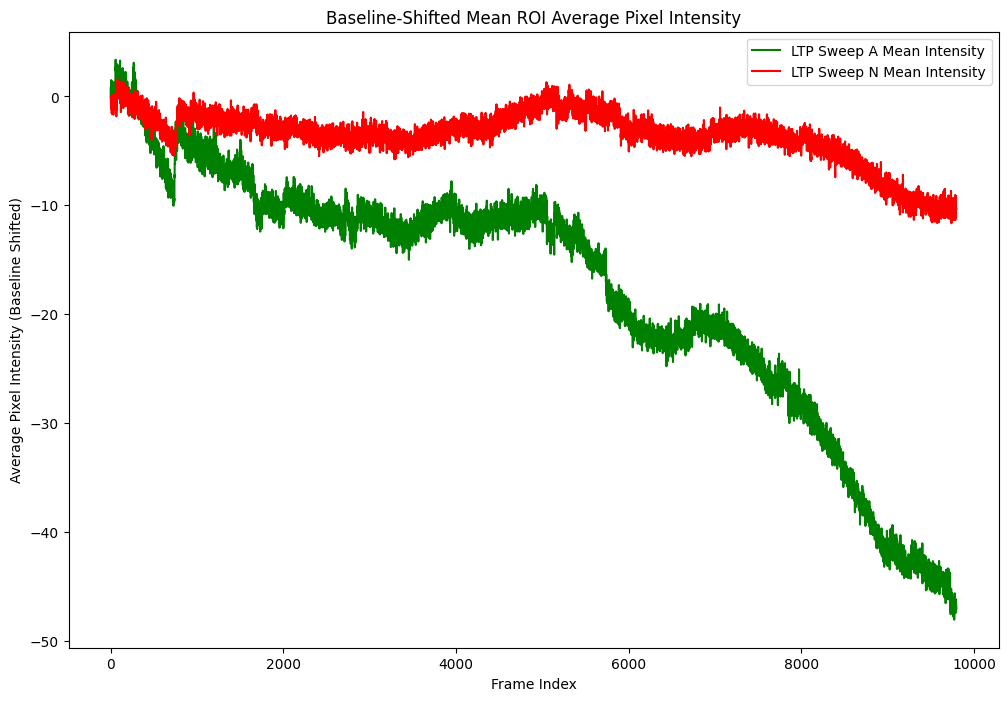

In [86]:

# Define your ROI coordinates here
roi_coords = [48,63,25,40]

# Example usage
plot_combined(LTP_tiffA, LTP_tiffN, roi_coords)


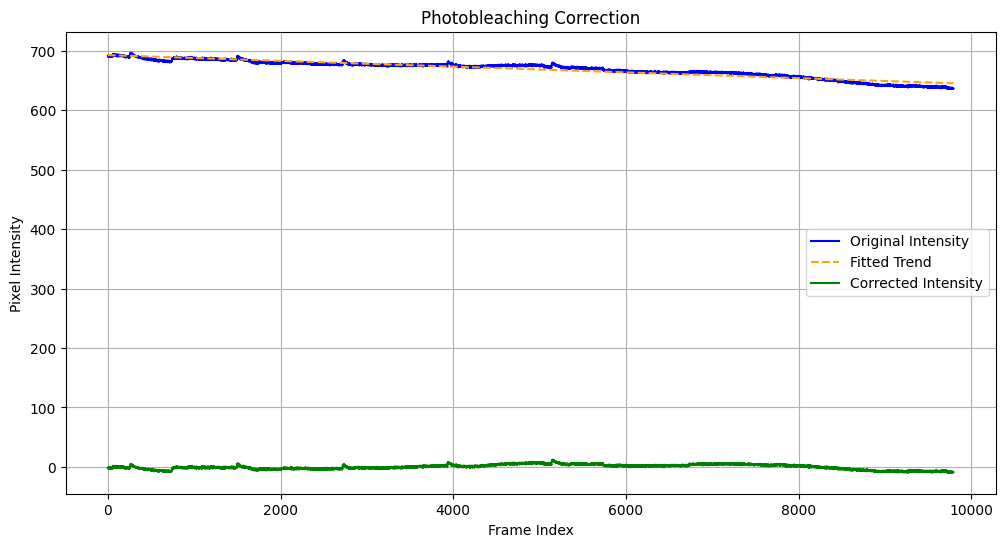

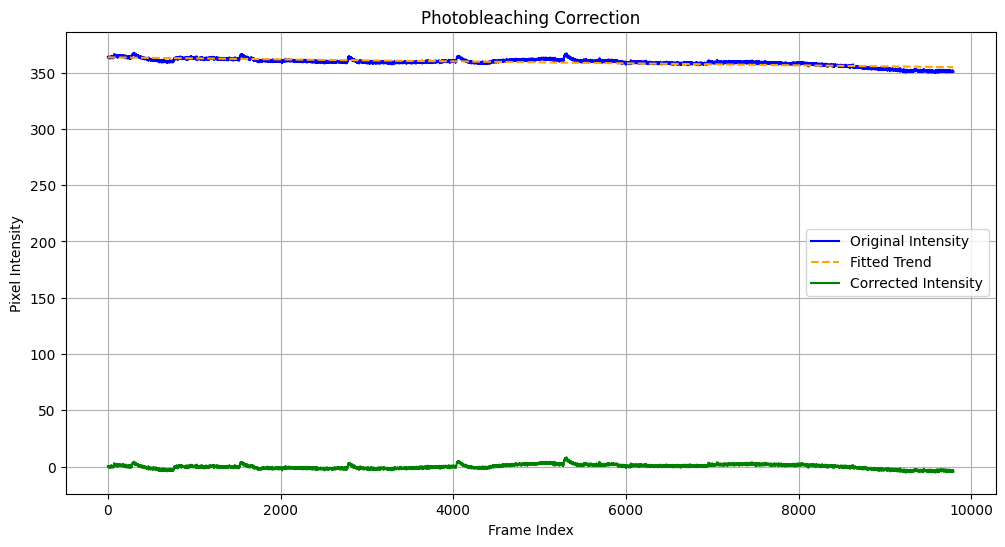

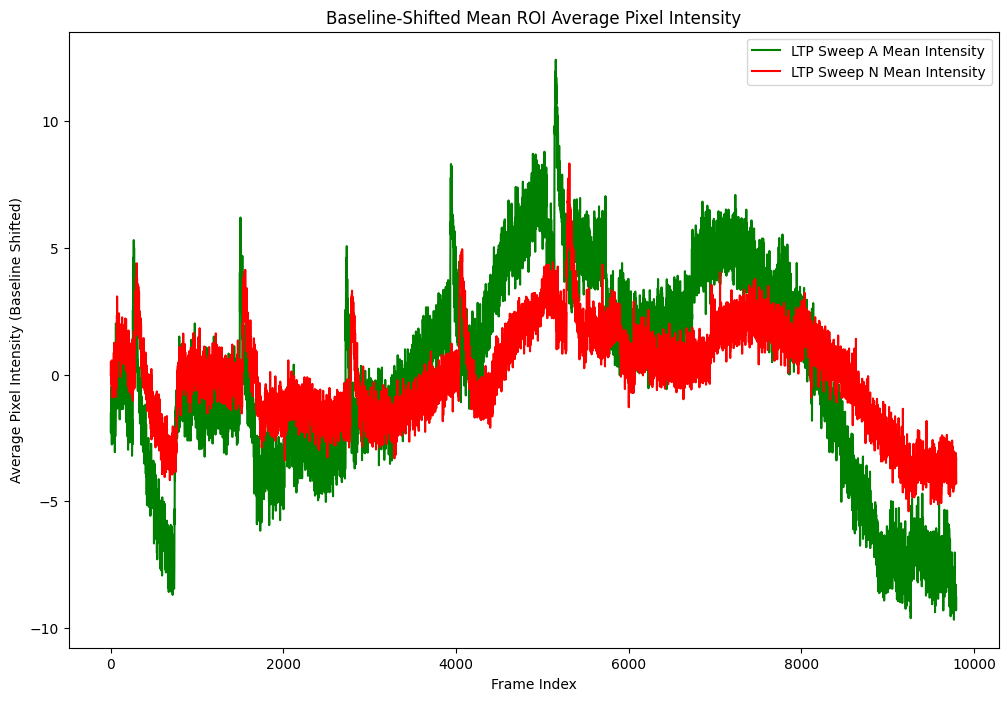

In [90]:
import numpy as np
import matplotlib.pyplot as plt
import imageio
from sklearn.linear_model import LinearRegression

# Ensure inline plotting in Jupyter Notebook
%matplotlib inline

def correct_photobleaching(intensity):
    x = np.arange(len(intensity)).reshape(-1, 1)
    y = intensity.reshape(-1, 1)

    # Fit linear regression model
    model = LinearRegression().fit(x, y)

    # Predict the trend
    trend = model.predict(x)

    # Subtract the trend from the original intensity
    corrected_intensity = intensity - trend.flatten()

    # Plot to confirm the regression and correction
    plt.figure(figsize=(12, 6))
    plt.plot(intensity, label='Original Intensity', color='blue')
    plt.plot(trend, label='Fitted Trend', color='orange', linestyle='--')
    plt.plot(corrected_intensity, label='Corrected Intensity', color='green')
    plt.xlabel('Frame Index')
    plt.ylabel('Pixel Intensity')
    plt.title('Photobleaching Correction')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return corrected_intensity

from scipy.signal import savgol_filter
def smooth_signal_savgol(signal, window_length=101, polyorder=3):
    return savgol_filter(signal, window_length, polyorder)

def baseline_shift_full_mean(intensity):
    mean_intensity = np.mean(intensity)
    return intensity - mean_intensity
###
def process_data(tiff_array, roi_coords, zscore=False, smooth=False):
    if roi_coords:
        x_start, x_end, y_start, y_end = roi_coords
        roi_avg_intensity = []

        for frame in tiff_array:
            roi = frame[y_start:y_end, x_start:x_end]
            avg_intensity = np.mean(roi)
            roi_avg_intensity.append(avg_intensity)

        roi_avg_intensity = np.array(roi_avg_intensity)
        
        # Correct for photobleaching
        roi_avg_intensity = correct_photobleaching(roi_avg_intensity)

        # Smoothing
        if smooth:
            roi_avg_intensity = smooth_signal_savgol(roi_avg_intensity)

        # Baseline shift
        baseline_shifted = baseline_shift_full_mean(roi_avg_intensity)
        return baseline_shifted
    else:
        print("No ROI coordinates provided.")
        return None

def plot_combined(LTP_tiffA, LTP_tiffN, roi_coords):
    """Plots LTP sweep data for both conditions on the same plot."""
    LTP_mean_traceA = process_data(LTP_tiffA, roi_coords, zscore=False, smooth=False)
    LTP_mean_traceN = process_data(LTP_tiffN, roi_coords, zscore=False, smooth=False)

    if LTP_mean_traceA is not None and LTP_mean_traceN is not None:
        frame_indices = np.arange(len(LTP_mean_traceA))

        plt.figure(figsize=(12, 8))

        # Plot LTP sweep A
        plt.plot(frame_indices, LTP_mean_traceA, label='LTP Sweep A Mean Intensity', color='green')

        # Plot LTP sweep N
        plt.plot(frame_indices, LTP_mean_traceN, label='LTP Sweep N Mean Intensity', color='red')

        plt.xlabel('Frame Index')
        plt.ylabel('Average Pixel Intensity (Baseline Shifted)')
        plt.title('Baseline-Shifted Mean ROI Average Pixel Intensity')
        plt.grid(False)
        plt.legend()
        plt.show()
    else:
        print("Error processing data.")
    return LTP_mean_traceA, LTP_mean_traceN

# Define your ROI coordinates here
roi_coords = [100,116,27,43]

# Example usage
LTP_mean_traceA, LTP_mean_traceN = plot_combined(LTP_tiffA, LTP_tiffN, roi_coords)


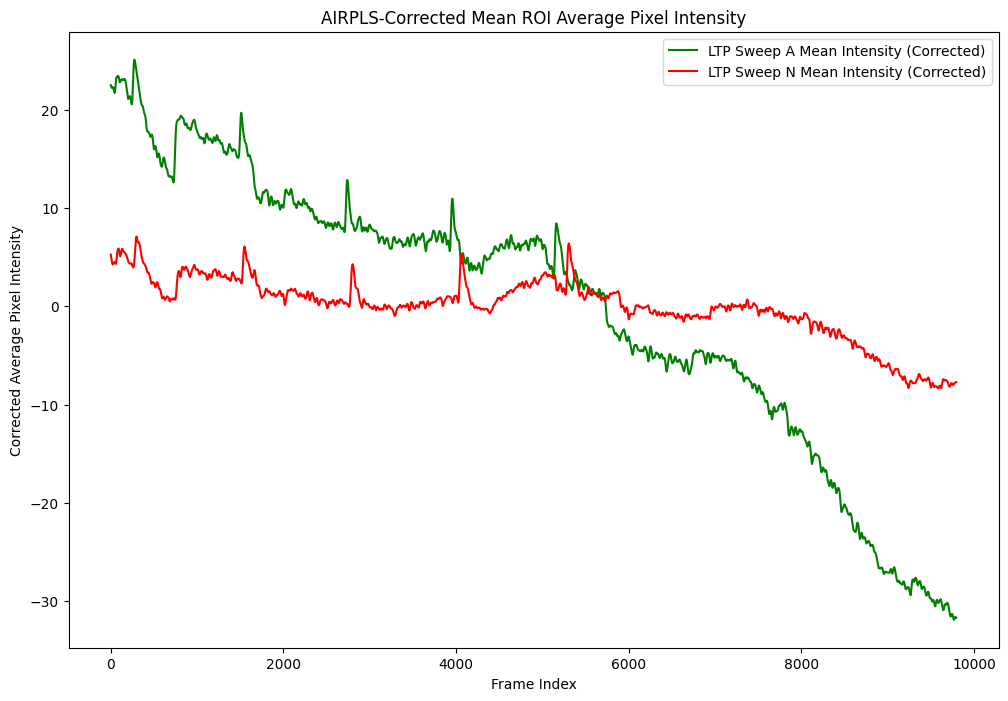

In [111]:
import numpy as np
import matplotlib.pyplot as plt
import imageio
from scipy.linalg import cho_solve, cho_factor
from scipy.signal import savgol_filter
from scipy.sparse.linalg import spsolve
from scipy import sparse

def baseline_shift_full_mean(intensity):
    mean_intensity = np.mean(intensity)
    return intensity - mean_intensity

def airPLS(y, lam=100, p=1, niter=15):
        L = len(y)
        D = sparse.diags([1, -2, 1], [0, -1, -2], shape=(L, L - 2))
        D = lam * D.dot(D.transpose())  # Precompute this term since it does not depend on `w`
        w = np.ones(L)
        W = sparse.spdiags(w, 0, L, L)
        z = np.zeros(len(y))
        for i in range(niter):
            W.setdiag(w)  # Do not create a new matrix, just update diagonal values
            Z = W + D
            z = spsolve(Z, w * y)
            w = p * (y > z) + (1 - p) * (y < z)
        return y - z

def process_data_with_airPLS(tiff_array, roi_coords, lam=100, p=1, niter=15):
    if roi_coords:
        x_start, x_end, y_start, y_end = roi_coords
        roi_avg_intensity = []

        for frame in tiff_array:
            roi = frame[y_start:y_end, x_start:x_end]
            avg_intensity = np.mean(roi)
            roi_avg_intensity.append(avg_intensity)

        roi_avg_intensity = np.array(roi_avg_intensity)

        # Apply the AIRPLS method for baseline correction
        baseline = airPLS(roi_avg_intensity, lam=lam, p=p, niter=niter)
        corrected_intensity = roi_avg_intensity - baseline
        
        mean_shifted = baseline_shift_full_mean(corrected_intensity)
        return mean_shifted

        return mean_shifted
    else:
        print("No ROI coordinates provided.")
        return None

def plot_combined_with_airPLS(LTP_tiffA,  LTP_tiffN, roi_coords):
    LTP_mean_traceA = process_data_with_airPLS(LTP_tiffA, roi_coords, lam=10, p=0.001, niter=100) #larger lambda - smoother
    LTP_mean_traceN = process_data_with_airPLS(LTP_tiffN, roi_coords, lam=10, p=0.001, niter=100)
    
    if LTP_mean_traceA is not None:
        frame_indices = np.arange(len(LTP_mean_traceA))

        plt.figure(figsize=(12, 8))

        # Plot LTP sweep A
        plt.plot(frame_indices, LTP_mean_traceA, label='LTP Sweep A Mean Intensity (Corrected)', color='green')
        plt.plot(frame_indices, LTP_mean_traceN, label='LTP Sweep N Mean Intensity (Corrected)', color='red')
        plt.xlabel('Frame Index')
        plt.ylabel('Corrected Average Pixel Intensity')
        plt.title('AIRPLS-Corrected Mean ROI Average Pixel Intensity')
        plt.grid(False)
        plt.legend()
        plt.show()
    else:
        print("Error processing data.")

# Define your ROI coordinates here
roi_coords = [100,116,27,43]

# Plot the data with AIRPLS correction
plot_combined_with_airPLS(LTP_tiffA,  LTP_tiffN, roi_coords)


In [112]:
result = LTP_mean_traceA - LTP_mean_traceN
result = result[0:8000]

Text(0, 0.5, 'Average Pixel Intensity (Baseline Shifted)')

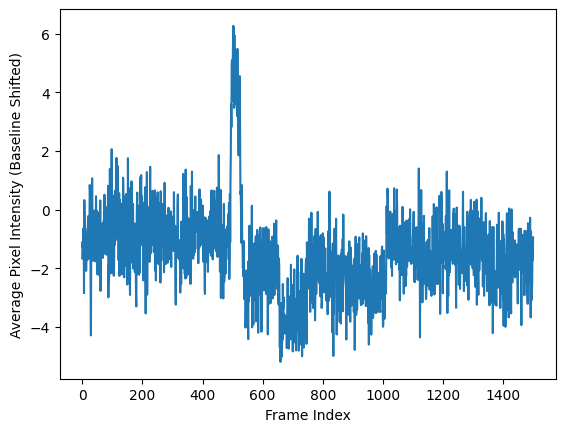

In [116]:
plt.plot(result[1000:2500])
plt.xlabel("Frame Index")
plt.ylabel("Average Pixel Intensity (Baseline Shifted)")